# Overlap Sweep: Iris Binary (versicolor vs virginica)

**What this notebook does:**
1. Loads Iris, drops setosa → binary classification: versicolor (−1) vs virginica (+1)
2. Adds 150 points per class following Iris distribution
3. Adds 50 synthetic points per class at 4 overlap levels: `0.1, 0.2, 0.3, 0.4`
4. For each dataset: trains a **SVM** and a **VQC (clean simulator)**
5. Evaluates each trained model on 3 conditions:
   - `sim → sim` : clean weights, clean evaluation (upper bound)
   - `sim → noisy` : clean weights, noisy Aer evaluation (degradation signal)
   - `SVM` : classical baseline
6. Plots different metrics across all conditions


## 1. Imports & Configuration

In [1]:
import os
import json
import pennylane as qml
from pennylane import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

# Circuit
N_QUBITS   = 4
N_LAYERS   = 7
N_FEATURES = 4
SHOTS_HW   = 512

# Training
LEARNING_RATE = 0.05
N_EPOCHS      = 50
BATCH_SIZE    = 16

MODELS_DIR = "models_overlap"
os.makedirs(MODELS_DIR, exist_ok=True)

# Overlap levels to sweep
OVERLAP_LEVELS = [0.1, 0.2, 0.3, 0.4]
N_SYNTHETIC    = 50   # synthetic points added per class per overlap level

IBM_TOKEN = "9SFzmmQ7Kaz0N9IXMfGSQWlCSyfhAWJG1HCK-8iruPYB"

print(f"PennyLane {qml.__version__}")
print(f"N_LAYERS={N_LAYERS}  SHOTS_HW={SHOTS_HW}")
print(f"Overlap sweep: {OVERLAP_LEVELS}  |  {N_SYNTHETIC} synthetic pts/class")


PennyLane 0.44.1
N_LAYERS=7  SHOTS_HW=512
Overlap sweep: [0.1, 0.2, 0.3, 0.4]  |  50 synthetic pts/class


## 2. IBM Backend & Noise Model

In [2]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer.noise import NoiseModel

service = QiskitRuntimeService(
    channel="ibm_quantum_platform",
    token=IBM_TOKEN
)

backends = service.backends(simulator=False, operational=True)
print([b.name for b in backends])


qiskit_runtime_service._discover_account:WARNING:2026-06-13 08:36:02,354: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-06-13 08:36:06,116: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: QML. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-13 08:36:06,117: Loading instance: QML, plan: open


['ibm_fez', 'ibm_marrakesh', 'ibm_kingston']


In [3]:
ibm_backend = service.backend("ibm_fez")
noise_model = NoiseModel.from_backend(ibm_backend)
print(f"Noise model loaded from: {ibm_backend.name}")

qiskit_runtime_service.backends:WARNING:2026-06-13 08:36:09,093: Using instance: QML, plan: open


Noise model loaded from: ibm_fez


## 3. Dataset Construction

**Binary task:** versicolor (class 1 → label −1) vs virginica (class 2 → label +1).  
Setosa is dropped — it is trivially separable and contributes nothing to the noise sensitivity study.

For each `overlap_std` in `[0.1, 0.2, 0.3, 0.4]`, we:
1. Start from the 100 real samples (50 versicolor + 50 virginica)
2. Compute the centroid of each class in the **scaled** feature space
3. Compute the midpoint between the two centroids
4. Sample `N_SYNTHETIC` points per class from a Gaussian centered at the midpoint  
   with std = `overlap_std` — these land directly in the decision boundary region
5. Split 70/30 train/test, stratified

The synthetic points are **identical across overlap levels except for the std**, so the
only variable is how much the classes bleed into each other.


In [4]:
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.metadata import SingleTableMetadata
import pandas as pd

def augment_with_copula(X_scaled, y_binary, n_per_class=150, seed=SEED):
    """
    Generate n_per_class samples per class ussing Gaussian Copula,
    using original distribution and correlations of Iris.
    """
    feature_cols = ['f0', 'f1', 'f2', 'f3']
    df = pd.DataFrame(X_scaled, columns=feature_cols)
    df['label'] = y_binary

    augmented_X, augmented_y = [X_scaled.copy()], [y_binary.copy()]

    for cls in [-1, 1]:
        subset = df[df['label'] == cls][feature_cols].reset_index(drop=True)

        metadata = SingleTableMetadata()
        metadata.detect_from_dataframe(subset)

        synth = GaussianCopulaSynthesizer(
            metadata,
            default_distribution='norm',
            enforce_min_max_values=True   # respeta el rango [0, π] automáticamente
        )
        synth.fit(subset)
        syn_df = synth.sample(num_rows=n_per_class)

        augmented_X.append(syn_df[feature_cols].values)
        augmented_y.append(np.full(n_per_class, float(cls)))

    return np.vstack(augmented_X), np.concatenate(augmented_y)


def build_binary_iris_datasets(overlap_levels, n_copula=150, n_synthetic=50, seed=SEED):
    """
    Step 1 — Copula: add n_copula samples per clase with Iris real distribution.
    Step 2 — Overlap: add n_synthetic samples per clase in decition frontier with controled std.

    Total per dataset: 100 real + 2×150 copula + 2×50 overlap
    """
    iris   = load_iris()
    mask   = iris.target != 0
    X_raw  = iris.data[mask].astype(np.float64)
    y_raw  = iris.target[mask]

    scaler   = MinMaxScaler(feature_range=(0, np.pi))
    X_scaled = scaler.fit_transform(X_raw)
    y_binary = np.where(y_raw == 2, 1, -1).astype(np.float64)

    # Paso 1: aumentar con copula — igual para todos los overlap levels
    # Se hace una sola vez fuera del loop porque no depende de std
    print("  Fitting Gaussian Copula...")
    X_base, y_base = augment_with_copula(X_scaled, y_binary,
                                          n_per_class=n_copula, seed=seed)
    print(f"  Base dataset after copula: {len(X_base)} samples "
          f"({int((y_base==1).sum())} pos, {int((y_base==-1).sum())} neg)")

    rng      = np.random.default_rng(seed)
    datasets = {}

    for std in overlap_levels:
        # Paso 2: añadir overlap en la frontera — varía por std
        c_neg    = X_base[y_base == -1].mean(axis=0)
        c_pos    = X_base[y_base ==  1].mean(axis=0)
        midpoint = (c_neg + c_pos) / 2
        offset   = (c_pos - c_neg) * 0.1

        syn_neg = rng.normal(loc=midpoint - offset, scale=std, size=(n_synthetic, N_FEATURES))
        syn_pos = rng.normal(loc=midpoint + offset, scale=std, size=(n_synthetic, N_FEATURES))
        syn_neg = np.clip(syn_neg, 0, np.pi)
        syn_pos = np.clip(syn_pos, 0, np.pi)

        X_aug = np.vstack([X_base, syn_neg, syn_pos])
        y_aug = np.concatenate([y_base,
                                np.full(n_synthetic, -1.0),
                                np.full(n_synthetic,  1.0)])

        X_train, X_test, y_train, y_test = train_test_split(
            X_aug, y_aug, test_size=0.3, random_state=seed, stratify=y_aug
        )
        datasets[std] = {
            "X_train": X_train, "y_train": y_train,
            "X_test" : X_test,  "y_test" : y_test,
            "n_total": len(X_aug),
            "scaler" : scaler,
        }
        print(f"  overlap={std:.2f}  total={len(X_aug)}  "
              f"train={len(X_train)}  test={len(X_test)}  "
              f"pos_train={int((y_train==1).sum())}  neg_train={int((y_train==-1).sum())}")

    return datasets

print("Building datasets for each overlap level...")
datasets = build_binary_iris_datasets(OVERLAP_LEVELS)

Building datasets for each overlap level...
  Fitting Gaussian Copula...
  Base dataset after copula: 400 samples (200 pos, 200 neg)
  overlap=0.10  total=500  train=350  test=150  pos_train=175  neg_train=175
  overlap=0.20  total=500  train=350  test=150  pos_train=175  neg_train=175
  overlap=0.30  total=500  train=350  test=150  pos_train=175  neg_train=175
  overlap=0.40  total=500  train=350  test=150  pos_train=175  neg_train=175


## 4. Visualise Datasets — Overlap Sweep

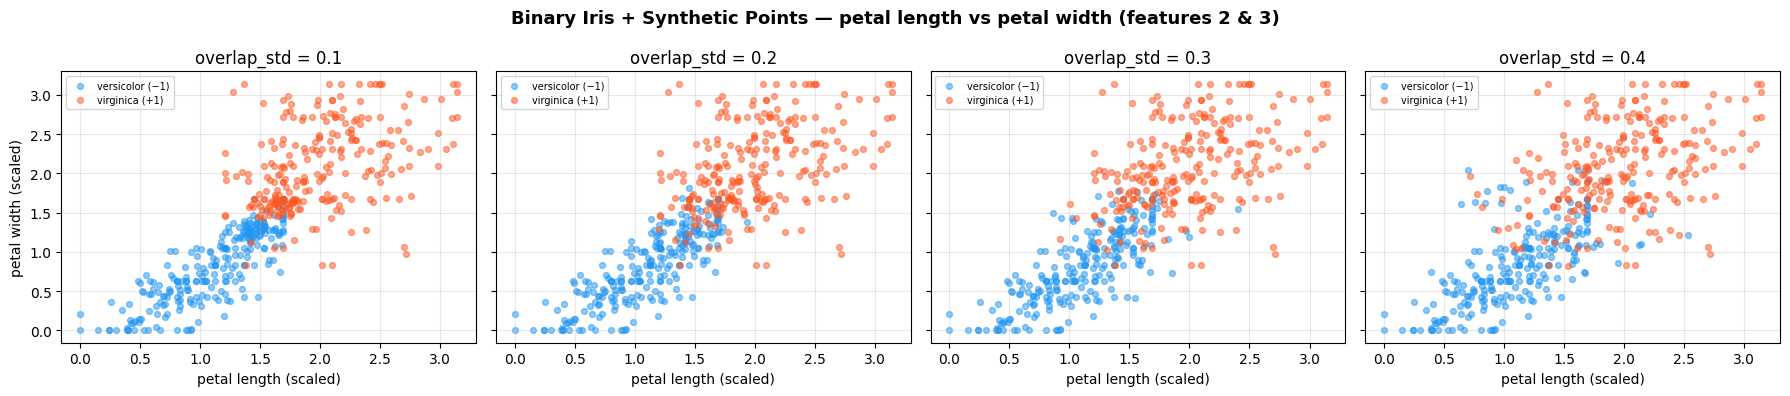

In [5]:
fig, axes = plt.subplots(1, len(OVERLAP_LEVELS), figsize=(18, 4), sharey=True)
fig.suptitle("Binary Iris + Synthetic Points — petal length vs petal width (features 2 & 3)",
             fontsize=13, fontweight='bold')

colors = {-1: "#2196F3", 1: "#FF5722"}
labels = {-1: "versicolor (−1)", 1: "virginica (+1)"}

for ax, std in zip(axes, OVERLAP_LEVELS):
    d = datasets[std]
    X_all = np.vstack([d["X_train"], d["X_test"]])
    y_all = np.concatenate([d["y_train"], d["y_test"]])

    # Original points (first 100 are the real Iris samples)
    for cls in [-1, 1]:
        idx = y_all == cls
        ax.scatter(X_all[idx, 2], X_all[idx, 3],
                   c=colors[cls], alpha=0.5, s=18, label=labels[cls])

    ax.set_title(f"overlap_std = {std}")
    ax.set_xlabel("petal length (scaled)")
    if ax == axes[0]:
        ax.set_ylabel("petal width (scaled)")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Circuit Architecture

Same VQC as `iris_vqc_antinoise_v2`:
- **Data reuploading**: `AngleEmbedding + StronglyEntanglingLayers` repeated `N_LAYERS` times
- **Measurement**: ⟨Z₀⟩ → sign → predicted label {+1, −1}
- **Clean circuit**: `default.qubit`, `diff_method=best` (Parameter-Shift)  
- **Noisy circuit**: `qiskit.aer` with `ibm_fez` noise model, `SHOTS_HW=512`

Binary task means **one circuit per overlap level** (not 3 as in 1-vs-All).


Weight shape: (7, 4, 3)  (84 parameters)


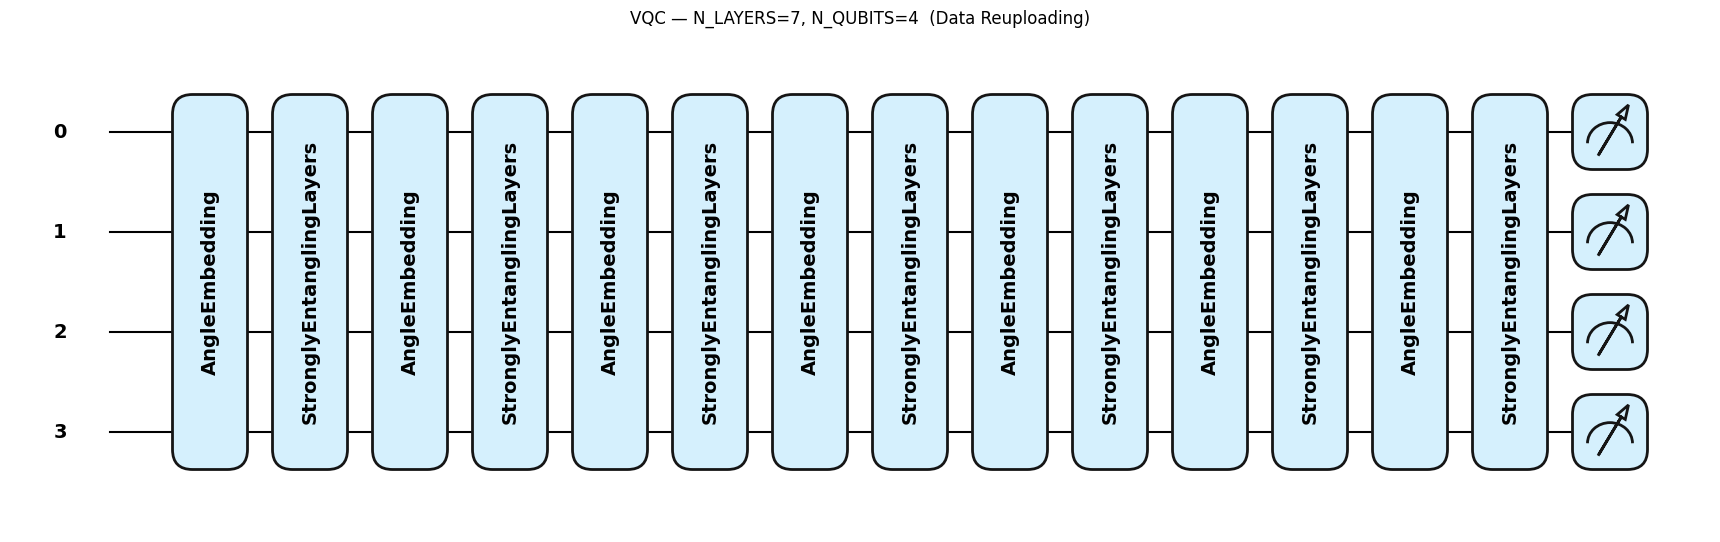

In [6]:
def create_vqc(device_name, n_qubits=N_QUBITS, n_layers=N_LAYERS,
               trainable=False, **device_kwargs):
    """
    trainable=True  → diff_method='best' (Parameter-Shift), for entrenamiento.
    trainable=False → without diff_method, for evaluation/mitiq.
    """
    device      = qml.device(device_name, wires=n_qubits, **device_kwargs)
    weight_shape = qml.StronglyEntanglingLayers.shape(n_layers=n_layers, n_wires=n_qubits)
    kwargs = {"diff_method": "best"} if trainable else {}

    @qml.qnode(device, **kwargs)
    def circuit(inputs, weights):
        for layer_idx in range(n_layers):
            qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')
            qml.StronglyEntanglingLayers(
                weights[layer_idx * (weight_shape[0] // n_layers):
                        (layer_idx + 1) * (weight_shape[0] // n_layers)],
                wires=range(n_qubits)
            )
        return qml.expval(qml.PauliZ(0) @ qml.PauliZ(1) @ qml.PauliZ(2) @ qml.PauliZ(3))

    return circuit, weight_shape, device


# Instantiate circuits — one clean + one noisy (shared across overlap levels,
# only the dataset changes; the circuit topology is the same)
sim_circuit,   weight_shape, _      = create_vqc('default.qubit', trainable=True)
noisy_circuit, weight_shape, hw_dev = create_vqc(
    'qiskit.aer', trainable=False,
    shots=SHOTS_HW, backend='qasm_simulator', noise_model=noise_model
)

print(f"Weight shape: {weight_shape}  ({np.prod(weight_shape)} parameters)")

# Draw circuit
dummy_w = np.zeros(weight_shape)
dummy_x = np.zeros(N_FEATURES)
fig, ax = qml.draw_mpl(sim_circuit, decimals=None, style="pennylane")(dummy_x, dummy_w)
ax.set_title(f"VQC — N_LAYERS={N_LAYERS}, N_QUBITS={N_QUBITS}  (Data Reuploading)")
plt.tight_layout()
plt.show()


## 6. Training

For each overlap level we train:
- **VQC (clean)**: Adam optimiser, `default.qubit`, Parameter-Shift gradients
- **SVM**: RBF kernel, `C=1.0`, `gamma=scale` — same train split

Models are cached to `models_overlap/` so re-running the notebook doesn't retrain.  
Cache key: `sim_overlap{std}_weights.npy` — delete to force retrain.


In [7]:
def mse_loss(predictions, targets):
    return np.mean((predictions - targets) ** 2)


def train_vqc(circuit, weight_shape, X_train, y_train,
              n_epochs=N_EPOCHS, lr=LEARNING_RATE,
              batch_size=BATCH_SIZE, label="",
              patience=8, min_delta=1e-4): 

    weights    = np.random.uniform(-np.pi, np.pi, weight_shape, requires_grad=True)
    opt        = qml.AdamOptimizer(stepsize=lr)
    loss_curve = []
    n_samples  = len(X_train)

    # Early stopping state
    best_loss    = np.inf
    best_weights = weights.copy()
    no_improve   = 0

    for epoch in range(n_epochs):
        perm   = np.random.permutation(n_samples)
        X_shuf = X_train[perm]
        y_shuf = y_train[perm]
        epoch_losses = []

        for start in range(0, n_samples, batch_size):
            X_b = X_shuf[start:start + batch_size]
            y_b = y_shuf[start:start + batch_size]

            def batch_cost(w):
                preds = np.array([circuit(x, w) for x in X_b])
                return mse_loss(preds, y_b)

            weights, loss_val = opt.step_and_cost(batch_cost, weights)
            epoch_losses.append(float(loss_val))

        mean_loss = float(np.mean(epoch_losses))
        loss_curve.append(mean_loss)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  [{label}] epoch {epoch+1:3d}/{n_epochs}  loss: {mean_loss:.4f}")

        # Early stopping check
        if mean_loss < best_loss - min_delta:
            best_loss    = mean_loss
            best_weights = weights.copy()
            no_improve   = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  [{label}] early stop at epoch {epoch+1}  best_loss: {best_loss:.4f}")
                return best_weights, loss_curve   # ← devuelve los mejores pesos, no los últimos

    return best_weights, loss_curve


def predict_binary(circuit, weights, X):
    scores = np.array([float(circuit(x, weights)) for x in X])
    return np.where(scores >= 0.0, 1, -1).astype(int)


def compute_metrics(y_true, y_pred):
    return {
        "accuracy" : accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=1,  zero_division=0),
        "recall"   : recall_score(y_true, y_pred,    pos_label=1,  zero_division=0),
        "f1"       : f1_score(y_true, y_pred,         pos_label=1, zero_division=0),
    }


In [8]:
# Train VQC (clean) + SVM for every overlap level
vqc_weights  = {}   # overlap_std → trained weights
vqc_losses   = {}   # overlap_std → loss curve
svm_models   = {}   # overlap_std → fitted SVC

for std in OVERLAP_LEVELS:
    d      = datasets[std]
    tag = f"{int(std * 100):03d}" # e.g. "010", "015", "020", "025", "030"
    w_path = os.path.join(MODELS_DIR, f"sim_overlap{tag}_weights.npy")
    l_path = os.path.join(MODELS_DIR, f"sim_overlap{tag}_loss.json")

    print(f"\n{'─'*55}")
    print(f" overlap_std = {std}  ({d['n_total']} samples)")
    print(f"{'─'*55}")

    # VQC clean
    if os.path.exists(w_path):
        print("  VQC weights found — loading from disk.")
        weights    = np.load(w_path)
        with open(l_path) as f:
            loss_curve = json.load(f)
    else:
        weights, loss_curve = train_vqc(
            sim_circuit, weight_shape,
            d["X_train"], d["y_train"],
            label=f"sim/overlap={std}"
        )
        np.save(w_path, np.array(weights))
        with open(l_path, "w") as f:
            json.dump(loss_curve, f)
        print(f"  VQC saved → {w_path}")

    vqc_weights[std] = weights
    vqc_losses[std]  = loss_curve

    # SVM
    svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=SEED)
    svm.fit(d["X_train"], d["y_train"])
    svm_models[std] = svm
    svm_acc = accuracy_score(d["y_test"], svm.predict(d["X_test"]))
    print(f"  SVM test accuracy: {svm_acc:.3f}")

print("\nAll models ready.")



───────────────────────────────────────────────────────
 overlap_std = 0.1  (500 samples)
───────────────────────────────────────────────────────
  VQC weights found — loading from disk.
  SVM test accuracy: 0.987

───────────────────────────────────────────────────────
 overlap_std = 0.2  (500 samples)
───────────────────────────────────────────────────────
  VQC weights found — loading from disk.
  SVM test accuracy: 0.947

───────────────────────────────────────────────────────
 overlap_std = 0.3  (500 samples)
───────────────────────────────────────────────────────
  VQC weights found — loading from disk.
  SVM test accuracy: 0.913

───────────────────────────────────────────────────────
 overlap_std = 0.4  (500 samples)
───────────────────────────────────────────────────────
  VQC weights found — loading from disk.
  SVM test accuracy: 0.907

All models ready.


## 7. Evaluation

Three conditions per overlap level:

| Condition | Weights | Evaluation circuit | Expected behaviour |
|---|---|---|---|
| `sim → sim` | VQC clean | `default.qubit` | Upper bound — unaffected by noise |
| `sim → noisy` | VQC clean | `qiskit.aer` + noise | Degrades as overlap increases AND circuit noise matters |
| `SVM` | RBF kernel | Classical | Classical ceiling for comparison |

The **key signal** is the gap between `sim → sim` and `sim → noisy`.  
If that gap grows with overlap, it means the noise is crossing the decision boundary —
and that is exactly where mitigation techniques will be useful.


In [10]:
rows = []

for std in OVERLAP_LEVELS:
    d = datasets[std]
    y_true = d["y_test"].astype(int)

    # Condition 1: sim weights → sim eval
    y_pred_ss = predict_binary(sim_circuit, vqc_weights[std], d["X_test"])
    m = compute_metrics(y_true, y_pred_ss)
    m.update({"overlap": std, "condition": "sim → sim"})
    rows.append(m)

    # Condition 2: sim weights → noisy eval
    y_pred_sn = predict_binary(noisy_circuit, vqc_weights[std], d["X_test"])
    m = compute_metrics(y_true, y_pred_sn)
    m.update({"overlap": std, "condition": "sim → noisy"})
    rows.append(m)

    # Condition 3: SVM
    y_pred_svm = svm_models[std].predict(d["X_test"]).astype(int)
    m = compute_metrics(y_true, y_pred_svm)
    m.update({"overlap": std, "condition": "SVM"})
    rows.append(m)

    print(f"overlap={std}  sim→sim={rows[-3]['accuracy']:.3f}  "
          f"sim→noisy={rows[-2]['accuracy']:.3f}  "
          f"SVM={rows[-1]['accuracy']:.3f}  "
          f"Δ(noisy-sim)={rows[-2]['accuracy']-rows[-3]['accuracy']:+.3f}")

results_df = pd.DataFrame(rows)[["overlap","condition","accuracy","precision","recall","f1"]]
pd.set_option('display.float_format', '{:.3f}'.format)
print("\n" + "="*70)
print(results_df.to_string(index=False))


overlap=0.1  sim→sim=0.980  sim→noisy=0.973  SVM=0.987  Δ(noisy-sim)=-0.007
overlap=0.2  sim→sim=0.933  sim→noisy=0.927  SVM=0.947  Δ(noisy-sim)=-0.007
overlap=0.3  sim→sim=0.887  sim→noisy=0.880  SVM=0.913  Δ(noisy-sim)=-0.007
overlap=0.4  sim→sim=0.867  sim→noisy=0.880  SVM=0.907  Δ(noisy-sim)=+0.013

 overlap   condition  accuracy  precision  recall    f1
   0.100   sim → sim     0.980      0.986   0.973 0.980
   0.100 sim → noisy     0.973      0.973   0.973 0.973
   0.100         SVM     0.987      0.987   0.987 0.987
   0.200   sim → sim     0.933      0.945   0.920 0.932
   0.200 sim → noisy     0.927      0.944   0.907 0.925
   0.200         SVM     0.947      0.947   0.947 0.947
   0.300   sim → sim     0.887      0.882   0.893 0.887
   0.300 sim → noisy     0.880      0.880   0.880 0.880
   0.300         SVM     0.913      0.908   0.920 0.914
   0.400   sim → sim     0.867      0.923   0.800 0.857
   0.400 sim → noisy     0.880      0.925   0.827 0.873
   0.400         SVM   

## 8. Visualisations

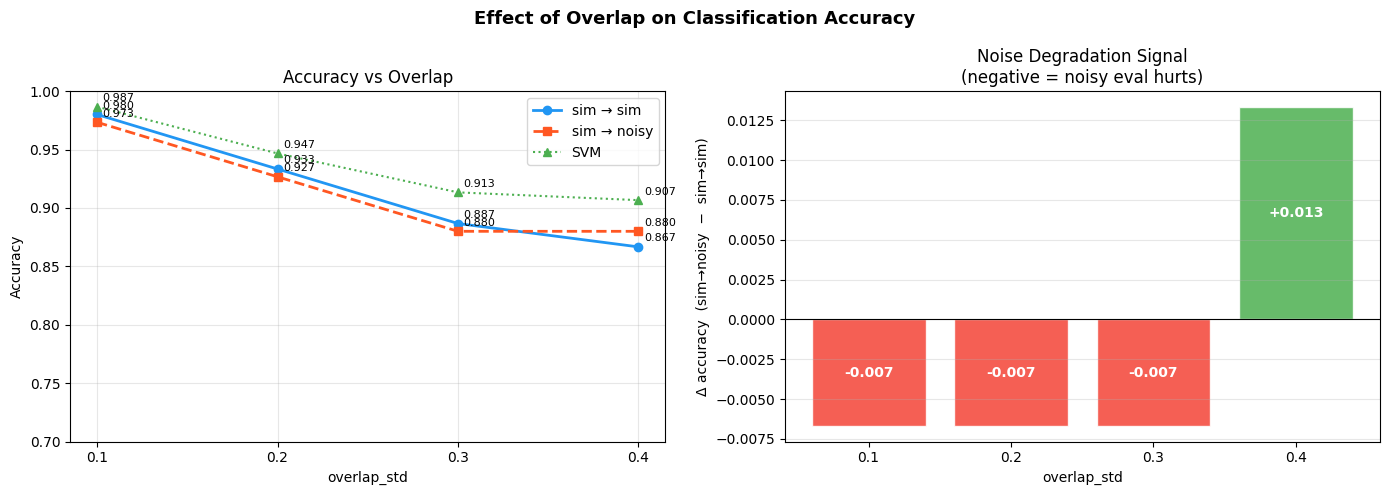

In [11]:
# 8.1 Accuracy vs overlap — main result
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Effect of Overlap on Classification Accuracy", fontsize=13, fontweight='bold')

condition_styles = {
    "sim → sim"  : {"color": "#2196F3", "marker": "o", "linestyle": "-",  "lw": 2.0},
    "sim → noisy": {"color": "#FF5722", "marker": "s", "linestyle": "--", "lw": 2.0},
    "SVM"        : {"color": "#4CAF50", "marker": "^", "linestyle": ":",  "lw": 1.5},
}

# Left: accuracy lines
ax = axes[0]
for cond, style in condition_styles.items():
    sub = results_df[results_df["condition"] == cond]
    ax.plot(sub["overlap"], sub["accuracy"],
            label=cond, **style)
    for _, row in sub.iterrows():
        ax.annotate(f"{row['accuracy']:.3f}",
                    (row["overlap"], row["accuracy"]),
                    textcoords="offset points", xytext=(4, 4), fontsize=8)

ax.set_xlabel("overlap_std")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs Overlap")
ax.set_xticks(OVERLAP_LEVELS)
ax.set_ylim(0.7, 1.0)  
ax.legend()
ax.grid(alpha=0.3)

# Right: Δ accuracy (sim→noisy minus sim→sim) — noise degradation signal
ax = axes[1]
sim_sim   = results_df[results_df["condition"] == "sim → sim"  ].set_index("overlap")["accuracy"]
sim_noisy = results_df[results_df["condition"] == "sim → noisy"].set_index("overlap")["accuracy"]
delta     = sim_noisy - sim_sim

bar_colors = ["#4CAF50" if d >= 0 else "#F44336" for d in delta.values]
bars = ax.bar([str(s) for s in OVERLAP_LEVELS], delta.values,
              color=bar_colors, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
for bar, d in zip(bars, delta.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_y() + bar.get_height() / 2, 
            f"{d:+.3f}", ha='center', va='center',
            fontsize=10, color='white', fontweight='bold') 
ax.set_xlabel("overlap_std")
ax.set_ylabel("Δ accuracy  (sim→noisy  −  sim→sim)")
ax.set_title("Noise Degradation Signal\n(negative = noisy eval hurts)")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

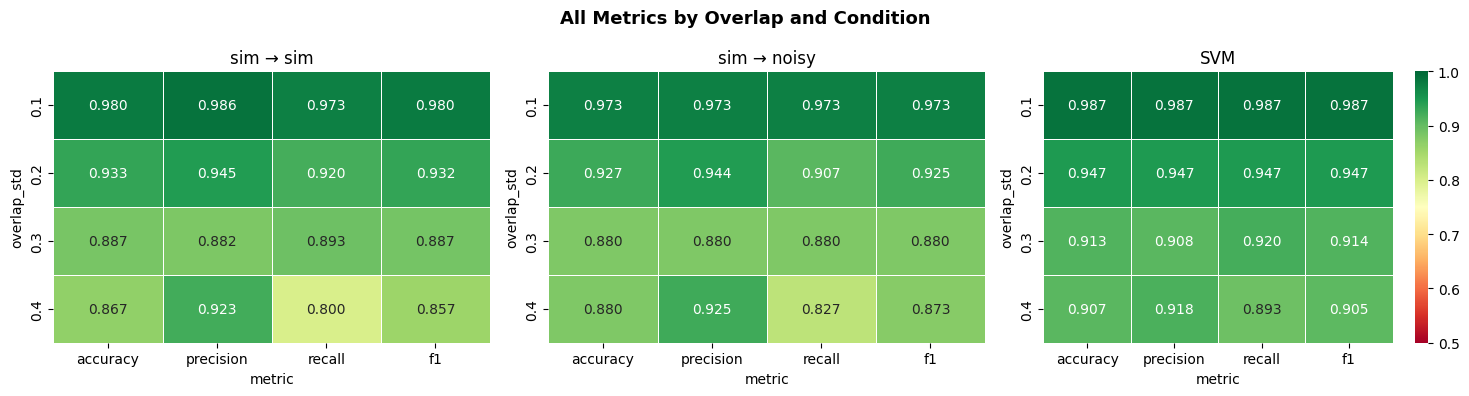

In [12]:
# 8.2 All metrics heatmap
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("All Metrics by Overlap and Condition", fontsize=13, fontweight='bold')

metrics = ["accuracy", "precision", "recall", "f1"]
for ax, cond in zip(axes, ["sim → sim", "sim → noisy", "SVM"]):
    sub   = results_df[results_df["condition"] == cond].set_index("overlap")[metrics]
    sns.heatmap(sub.astype(float), annot=True, fmt=".3f",
                cmap="RdYlGn", vmin=0.5, vmax=1.0,
                ax=ax, linewidths=0.5, cbar=(ax == axes[-1]))
    ax.set_title(cond)
    ax.set_xlabel("metric")
    ax.set_ylabel("overlap_std")

plt.tight_layout()
plt.show()


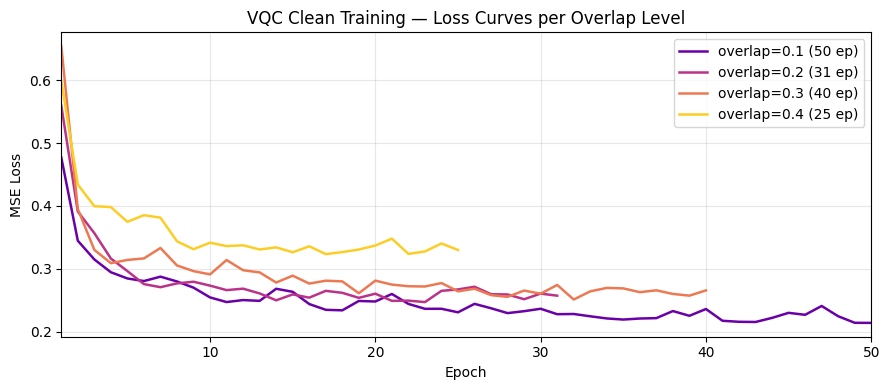

In [13]:
# 8.3 Loss curves — VQC clean training
fig, ax = plt.subplots(figsize=(9, 4))
palette = plt.cm.plasma(np.linspace(0.2, 0.9, len(OVERLAP_LEVELS)))

for std, color in zip(OVERLAP_LEVELS, palette):
    loss = vqc_losses[std]
    epochs_run = len(loss)                    
    ax.plot(range(1, epochs_run + 1), loss,
            label=f"overlap={std} ({epochs_run} ep)", color=color, linewidth=1.8)

ax.set_xlim(1, N_EPOCHS)     
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("VQC Clean Training — Loss Curves per Overlap Level")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


overlap=0.1  |⟨Z₀⟩| sim=0.601  noisy=0.333  ratio=0.568  Δ⟨Z₀⟩=+0.0007 ± 0.2925  MSE sim=0.2155  noisy=0.4673  ΔMSE=+0.2518
overlap=0.2  |⟨Z₀⟩| sim=0.586  noisy=0.318  ratio=0.552  Δ⟨Z₀⟩=+0.0108 ± 0.2929  MSE sim=0.2678  noisy=0.5044  ΔMSE=+0.2366
overlap=0.3  |⟨Z₀⟩| sim=0.586  noisy=0.324  ratio=0.561  Δ⟨Z₀⟩=+0.0092 ± 0.2861  MSE sim=0.3542  noisy=0.5585  ΔMSE=+0.2043
overlap=0.4  |⟨Z₀⟩| sim=0.575  noisy=0.309  ratio=0.543  Δ⟨Z₀⟩=+0.0463 ± 0.2852  MSE sim=0.3921  noisy=0.5735  ΔMSE=+0.1814


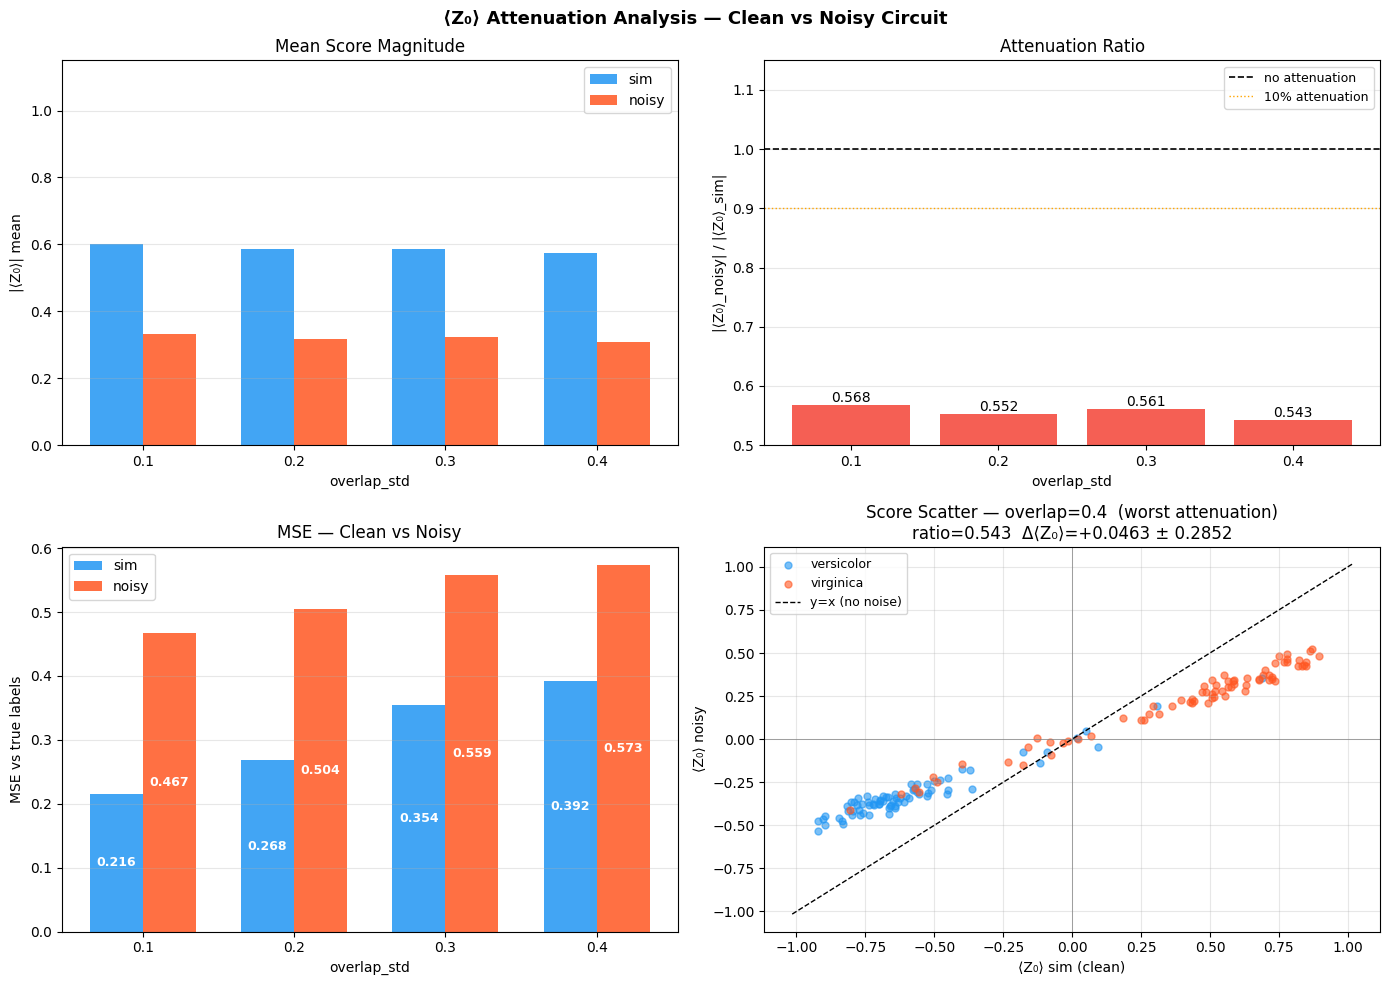

In [14]:
# Attenuation Analisis ⟨Z₀⟩
attenuation_rows = []

for std in OVERLAP_LEVELS:
    d = datasets[std]
    w = vqc_weights[std]

    scores_sim   = np.array([float(sim_circuit(x, w))   for x in d["X_test"]])
    scores_noisy = np.array([float(noisy_circuit(x, w)) for x in d["X_test"]])

    mask     = np.abs(scores_sim) > 0.05
    ratio    = np.abs(scores_noisy[mask]) / np.abs(scores_sim[mask])
    delta_z0 = scores_noisy - scores_sim

    mse_sim   = float(np.mean((scores_sim   - d["y_test"]) ** 2))
    mse_noisy = float(np.mean((scores_noisy - d["y_test"]) ** 2))

    attenuation_rows.append({
        "overlap"      : std,
        "mean_sim"     : float(np.mean(np.abs(scores_sim))),
        "mean_noisy"   : float(np.mean(np.abs(scores_noisy))),
        "mean_ratio"   : float(np.mean(ratio)),
        "mean_delta_z0": float(np.mean(delta_z0)),
        "std_delta_z0" : float(np.std(delta_z0)),
        "mse_sim"      : mse_sim,
        "mse_noisy"    : mse_noisy,
        "scores_sim"   : scores_sim,
        "scores_noisy" : scores_noisy,
        "y_test"       : d["y_test"],
    })
    print(f"overlap={std}  |⟨Z₀⟩| sim={attenuation_rows[-1]['mean_sim']:.3f}  "
          f"noisy={attenuation_rows[-1]['mean_noisy']:.3f}  "
          f"ratio={attenuation_rows[-1]['mean_ratio']:.3f}  "
          f"Δ⟨Z₀⟩={attenuation_rows[-1]['mean_delta_z0']:+.4f} ± {attenuation_rows[-1]['std_delta_z0']:.4f}  "
          f"MSE sim={mse_sim:.4f}  noisy={mse_noisy:.4f}  ΔMSE={mse_noisy - mse_sim:+.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("⟨Z₀⟩ Attenuation Analysis — Clean vs Noisy Circuit",
             fontsize=13, fontweight='bold')

# [0,0] Mean Score Magnitud |⟨Z₀⟩|
ax    = axes[0, 0]
x     = np.arange(len(OVERLAP_LEVELS))
bar_w = 0.35
means_s = [r["mean_sim"]   for r in attenuation_rows]
means_n = [r["mean_noisy"] for r in attenuation_rows]
ax.bar(x - bar_w/2, means_s, bar_w, label="sim",   color="#2196F3", alpha=0.85)
ax.bar(x + bar_w/2, means_n, bar_w, label="noisy", color="#FF5722", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in OVERLAP_LEVELS])
ax.set_xlabel("overlap_std")
ax.set_ylabel("|⟨Z₀⟩| mean")
ax.set_title("Mean Score Magnitude")
ax.set_ylim(0.0, 1.15)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# [0,1] Attenuation ratio
ax     = axes[0, 1]
ratios = [r["mean_ratio"] for r in attenuation_rows]
colors = ["#4CAF50" if r >= 0.95 else "#FF9800" if r >= 0.85 else "#F44336"
          for r in ratios]
bars = ax.bar([str(s) for s in OVERLAP_LEVELS], ratios, color=colors, alpha=0.85)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2, label='no attenuation')
ax.axhline(0.9, color='orange', linestyle=':', linewidth=1.0, label='10% attenuation')
for bar, r in zip(bars, ratios):
    ax.text(bar.get_x() + bar.get_width() / 2, r + 0.005,
            f"{r:.3f}", ha='center', fontsize=10)
ax.set_xlabel("overlap_std")
ax.set_ylabel("|⟨Z₀⟩_noisy| / |⟨Z₀⟩_sim|")
ax.set_title("Attenuation Ratio")
ax.set_ylim(0.5, 1.15)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# [1,0] MSE sim vs noisy
ax    = axes[1, 0]
mse_s = [r["mse_sim"]   for r in attenuation_rows]
mse_n = [r["mse_noisy"] for r in attenuation_rows]
b1 = ax.bar(x - bar_w/2, mse_s, bar_w, label="sim",   color="#2196F3", alpha=0.85)
b2 = ax.bar(x + bar_w/2, mse_n, bar_w, label="noisy", color="#FF5722", alpha=0.85)
for bars_g, vals in [(b1, mse_s), (b2, mse_n)]:
    for bar, v in zip(bars_g, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() / 2,
                f"{v:.3f}", ha='center', va='center',
                fontsize=9, color='white', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([str(s) for s in OVERLAP_LEVELS])
ax.set_xlabel("overlap_std")
ax.set_ylabel("MSE vs true labels")
ax.set_title("MSE — Clean vs Noisy")
ax.legend()
ax.grid(axis='y', alpha=0.3)

# [1,1] Scatter ⟨Z₀⟩ sim vs noisy
ax = axes[1, 1]
_worst_idx = int(np.argmin([r["mean_ratio"] for r in attenuation_rows]))
r          = attenuation_rows[_worst_idx]
for cls, color, name in [(-1, "#2196F3", "versicolor"), (1, "#FF5722", "virginica")]:
    idx = r["y_test"] == cls
    ax.scatter(r["scores_sim"][idx], r["scores_noisy"][idx],
               c=color, alpha=0.6, s=25, label=name)
lim = max(np.abs(r["scores_sim"]).max(), np.abs(r["scores_noisy"]).max()) * 1.1
ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=1.0, label='y=x (no noise)')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.set_xlabel("⟨Z₀⟩ sim (clean)")
ax.set_ylabel("⟨Z₀⟩ noisy")
ax.set_title(f"Score Scatter — overlap={r['overlap']}  (worst attenuation)\n"
             f"ratio={r['mean_ratio']:.3f}  "
             f"Δ⟨Z₀⟩={r['mean_delta_z0']:+.4f} ± {r['std_delta_z0']:.4f}")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 9. Improve Model with biggest overlap 

In [15]:
# Select most negative noisy overlap Δ
sim_sim_acc   = results_df[results_df["condition"] == "sim → sim"  ].set_index("overlap")["accuracy"]
sim_noisy_acc = results_df[results_df["condition"] == "sim → noisy"].set_index("overlap")["accuracy"]
delta_acc     = sim_noisy_acc - sim_sim_acc

best_overlap = delta_acc.idxmin()
print(f"Overlap selected: {best_overlap}  (Δ accuracy = {delta_acc[best_overlap]:+.4f})")

d_best = datasets[best_overlap]
w_best = vqc_weights[best_overlap]
y_true = d_best["y_test"]

Overlap selected: 0.2  (Δ accuracy = -0.0067)


In [16]:
from qiskit_aer import AerSimulator
import mthree
from mitiq.zne.scaling import fold_global, fold_gates_at_random
from mitiq.zne.inference import RichardsonFactory, LinearFactory

backend_aer = AerSimulator(noise_model=noise_model)

print("Calibrating REM (mthree)...")
mit = mthree.M3Mitigation(backend_aer)
mit.cals_from_system(range(N_QUBITS), shots=SHOTS_HW)

Calibrating REM (mthree)...


In [17]:
# Baseline Noisy

def score_baseline(weights, x):
    return float(noisy_circuit(x, weights))

In [18]:
# REM (Readout Error Mitigation using Mthree) 
# REM needs counts to apply its mitigation matrix, need a circuit that finishes with qml.counts()
@qml.qnode(hw_dev)
def counts_qnode(inputs, weights):
    for layer_idx in range(N_LAYERS):
        qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
        qml.StronglyEntanglingLayers(
            weights[layer_idx * (weight_shape[0] // N_LAYERS):
                    (layer_idx + 1) * (weight_shape[0] // N_LAYERS)],
            wires=range(N_QUBITS)
        )
    return qml.counts(wires=range(N_QUBITS))

def score_rem(weights, x):
    counts = counts_qnode(x, weights)
    
    # Formatear claves de tupla a string (ej. (0,1,0,1) -> "0101")
    clean_counts = {
        ("".join(map(str, k)) if isinstance(k, tuple) else str(k)): v 
        for k, v in counts.items()
    }
    
    # Aplicar mitigación M3
    quasi = mit.apply_correction(clean_counts, range(N_QUBITS))
    
    # Recalcular la paridad global Z0⊗Z1⊗Z2⊗Z3
    expval = 0.0
    for bitstring, prob in quasi.items():
        parity = 1 if bitstring.count('1') % 2 == 0 else -1
        expval += parity * prob
    return float(expval)

In [20]:
# ZNE (Global Folding + Richardson)
zne_qnode = qml.mitigate_with_zne(
    noisy_circuit,
    scale_factors=[1.0, 2.0, 3.0],
    folding=fold_global,
    extrapolate=RichardsonFactory.extrapolate
)

def score_zne(weights, x):
    return float(zne_qnode(x, weights))

In [21]:
# Digital ZNE (Gate Folding + Linear)
digital_zne_qnode = qml.mitigate_with_zne(
    noisy_circuit,
    scale_factors=[1.0, 3.0],
    folding=fold_gates_at_random,
    extrapolate=LinearFactory.extrapolate
)

def score_digital_zne(weights, x):
    return float(digital_zne_qnode(x, weights))

In [22]:
# Evaluate all techniques
techniques = {
    "baseline"    : score_baseline,
    "REM"         : score_rem,
    "ZNE"         : score_zne,
    "Digital ZNE" : score_digital_zne,
}

def get_scores(predict_fn, weights, X):
    return np.array([predict_fn(weights, x) for x in X])

def score_to_pred(scores):
    return np.where(scores >= 0.0, 1, -1).astype(int)

def compute_all_metrics(scores, y_true, scores_ref):
    y_pred = score_to_pred(scores)
    mask   = np.abs(scores_ref) > 0.05
    ratio  = np.abs(scores[mask]) / np.abs(scores_ref[mask])
    return {
        "accuracy"   : accuracy_score(y_true.astype(int), y_pred),
        "precision"  : precision_score(y_true.astype(int), y_pred, zero_division=0),
        "recall"     : recall_score(y_true.astype(int), y_pred, zero_division=0),
        "f1"         : f1_score(y_true.astype(int), y_pred, zero_division=0),
        "mse"        : float(np.mean((scores - y_true) ** 2)),
        "mean_abs_z0": float(np.mean(np.abs(scores))),
        "attenuation": float(np.mean(ratio)),
    }

# Simulation Ceiling
scores_sim_ref = np.array([float(sim_circuit(x, w_best)) for x in d_best["X_test"]])
ref_metrics = compute_all_metrics(scores_sim_ref, y_true, scores_sim_ref)
ref_metrics["attenuation"] = 1.0  

mitigation_results = {"sim (ceiling)": ref_metrics}

# Execute techniques
for name, score_fn in techniques.items():
    print(f"\nEvaluating: {name}...")
    scores = get_scores(score_fn, w_best, d_best["X_test"])
    m = compute_all_metrics(scores, y_true, scores_sim_ref)
    mitigation_results[name] = m
    print(f"  acc={m['accuracy']:.3f}  f1={m['f1']:.3f}  "
          f"mse={m['mse']:.4f}  |Z0|={m['mean_abs_z0']:.3f}  "
          f"att={m['attenuation']:.3f}")

print(f"\n{'─'*60}")
print(f" sim (ceiling): acc={ref_metrics['accuracy']:.3f}  "
      f"f1={ref_metrics['f1']:.3f}  mse={ref_metrics['mse']:.4f}  "
      f"|Z0|={ref_metrics['mean_abs_z0']:.3f}")


Evaluating: baseline...
  acc=0.933  f1=0.932  mse=0.5085  |Z0|=0.318  att=0.546

Evaluating: REM...
  acc=0.947  f1=0.946  mse=0.4558  |Z0|=0.362  att=0.628

Evaluating: ZNE...
  acc=0.907  f1=0.905  mse=0.4778  |Z0|=0.410  att=0.800

Evaluating: Digital ZNE...
  acc=0.920  f1=0.918  mse=0.5303  |Z0|=0.307  att=0.527

────────────────────────────────────────────────────────────
 sim (ceiling): acc=0.933  f1=0.932  mse=0.2678  |Z0|=0.586


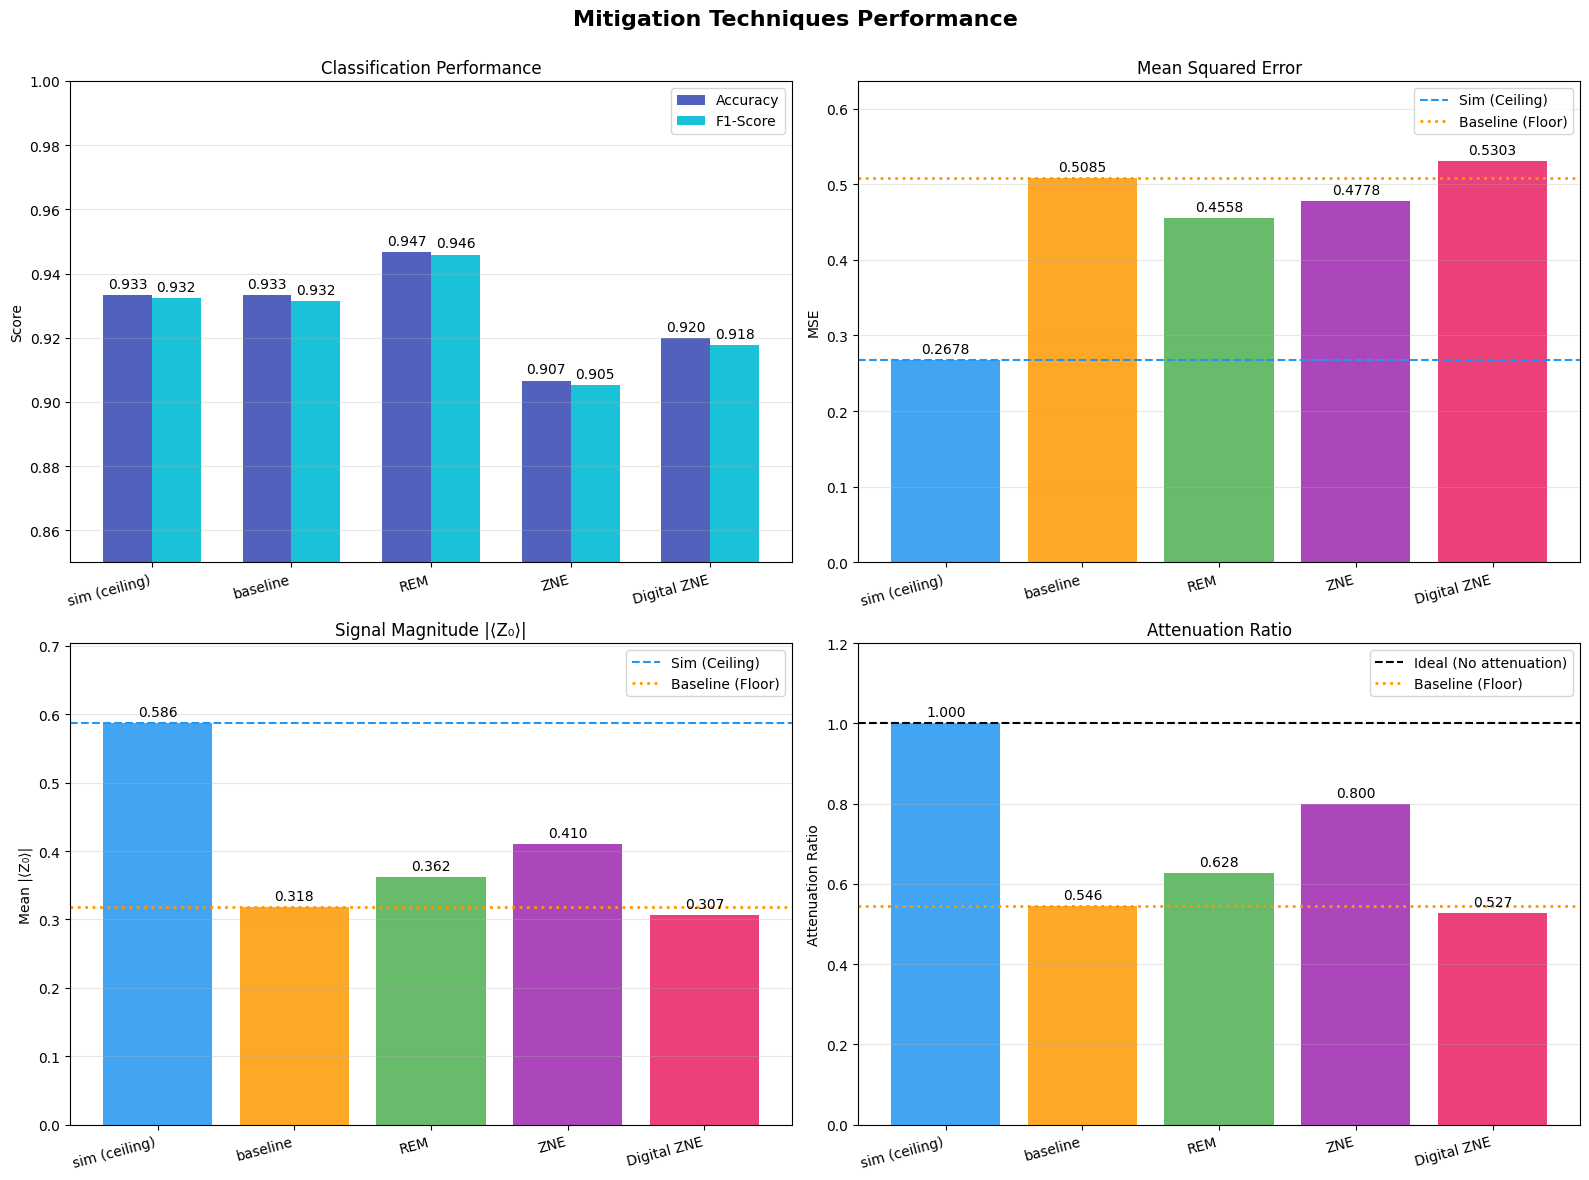

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data
names = list(mitigation_results.keys())
acc = [mitigation_results[n]['accuracy'] for n in names]
f1 = [mitigation_results[n]['f1'] for n in names]
mse = [mitigation_results[n]['mse'] for n in names]
z0 = [mitigation_results[n]['mean_abs_z0'] for n in names]
att = [mitigation_results[n]['attenuation'] for n in names]

# Find baseline index dynamically to plot the floor lines correctly
baseline_idx = names.index("baseline")
baseline_mse = mse[baseline_idx]
baseline_z0 = z0[baseline_idx]
baseline_att = att[baseline_idx]

# Color configuration
color_sim = "#2196F3"    # Blue
color_base = "#FF9800"   # Orange
color_rem = "#4CAF50"    # Green
color_zne = "#9C27B0"    # Purple
color_dzne = "#E91E63"   # Pink
colors = [color_sim, color_base, color_rem, color_zne, color_dzne]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f"Mitigation Techniques Performance", fontsize=16, fontweight='bold')

# Helper function to add value labels on top of the bars
def annotate_bars(ax, format_str="{:.3f}"):
    for p in ax.patches:
        ax.annotate(format_str.format(p.get_height()), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 8), 
                    textcoords='offset points', fontsize=10)


# Accuracy & F1-Score (Grouped bars)
ax = axes[0, 0]
x = np.arange(len(names))
width = 0.35

bar1 = ax.bar(x - width/2, acc, width, label='Accuracy', color='#3F51B5', alpha=0.9)
bar2 = ax.bar(x + width/2, f1, width, label='F1-Score', color='#00BCD4', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel("Score")
ax.set_title("Classification Performance")
ax.set_ylim(0.85, 1.0) # Zoom in the top part to see differences
ax.legend()
annotate_bars(ax, "{:.3f}")
ax.grid(axis='y', alpha=0.3)


# Mean Squared Error (MSE)
ax = axes[0, 1]
ax.bar(names, mse, color=colors, alpha=0.85)

# Horizontal lines for Ceiling and Floor
ax.axhline(mse[0], color=color_sim, linestyle='--', linewidth=1.5, label='Sim (Ceiling)')
ax.axhline(baseline_mse, color=color_base, linestyle=':', linewidth=2.0, label='Baseline (Floor)')

ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel("MSE")
ax.set_title("Mean Squared Error")
ax.set_ylim(0, max(mse) * 1.2)
ax.legend()
annotate_bars(ax, "{:.4f}")
ax.grid(axis='y', alpha=0.3)


# Signal Magnitude |⟨Z₀⟩|
ax = axes[1, 0]
ax.bar(names, z0, color=colors, alpha=0.85)

# Horizontal lines for Ceiling and Floor
ax.axhline(z0[0], color=color_sim, linestyle='--', linewidth=1.5, label='Sim (Ceiling)')
ax.axhline(baseline_z0, color=color_base, linestyle=':', linewidth=2.0, label='Baseline (Floor)')

ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel("Mean |⟨Z₀⟩|")
ax.set_title("Signal Magnitude |⟨Z₀⟩|")
ax.set_ylim(0, max(z0) * 1.2)
ax.legend()
annotate_bars(ax, "{:.3f}")
ax.grid(axis='y', alpha=0.3)


# Attenuation Ratio
ax = axes[1, 1]
ax.bar(names, att, color=colors, alpha=0.85)

# Horizontal lines for Ideal and Floor
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='Ideal (No attenuation)')
ax.axhline(baseline_att, color=color_base, linestyle=':', linewidth=2.0, label='Baseline (Floor)')

ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylabel("Attenuation Ratio")
ax.set_title("Attenuation Ratio")
ax.set_ylim(0, 1.2)
ax.legend()
annotate_bars(ax, "{:.3f}")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.subplots_adjust(top=0.92) # Adjust so title does not overlap
plt.show()

# 10. NOISE-AWARE TRAINING (NAT) 

In [43]:
# 10. NOISE-AWARE TRAINING (NAT) SETUP & SPSA OPTIMIZER

from pennylane import numpy as np
print(f"--- Starting NAT experiments on overlap: {best_overlap} ---")

dev_noisy_train = qml.device(
    'qiskit.aer', 
    wires=N_QUBITS, 
    shots=SHOTS_HW, 
    backend='qasm_simulator', 
    noise_model=noise_model,
    optimization_level=0  # Critical for Speed
)


# COST FUNCTIONS

# Cost A: Basic NAT
@qml.qnode(dev_noisy_train)
def nat_basic_qnode(inputs, weights):
    for layer_idx in range(N_LAYERS):
        qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
        qml.StronglyEntanglingLayers(
            weights[layer_idx * (weight_shape[0] // N_LAYERS):
                    (layer_idx + 1) * (weight_shape[0] // N_LAYERS)],
            wires=range(N_QUBITS)
        )
    return qml.expval(qml.PauliZ(0) @ qml.PauliZ(1) @ qml.PauliZ(2) @ qml.PauliZ(3))

def cost_a_nat_basic(weights, X_batch, y_batch):
    preds = nat_basic_qnode(X_batch, weights)   
    return np.mean((np.array(preds) - y_batch) ** 2)

# Cost B: NAT + REM 
@qml.qnode(dev_noisy_train)
def nat_counts_qnode(inputs, weights):
    for layer_idx in range(N_LAYERS):
        qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')
        qml.StronglyEntanglingLayers(
            weights[layer_idx * (weight_shape[0] // N_LAYERS):
                    (layer_idx + 1) * (weight_shape[0] // N_LAYERS)],
            wires=range(N_QUBITS)
        )
    return qml.counts(wires=range(N_QUBITS))

def cost_b_nat_rem(weights, X_batch, y_batch):
    preds = []
    for x in X_batch:
        counts = nat_counts_qnode(x, weights)
        clean_counts = {("".join(map(str, k)) if isinstance(k, tuple) else str(k)): v 
                        for k, v in counts.items()}
        quasi = mit.apply_correction(clean_counts, range(N_QUBITS))
        expval = sum(prob * (1 if bitstring.count('1') % 2 == 0 else -1) 
                     for bitstring, prob in quasi.items())
        preds.append(expval)
    return np.mean((np.array(preds) - y_batch) ** 2)


# SPSA TRAINING LOOP
def train_spsa(cost_fn, initial_weights, X_train, y_train, epochs=10, batch_size=32, label="", print_freq=1):
    
    n_samples = len(X_train)
    steps_per_epoch = int(np.ceil(n_samples / batch_size))
    total_steps = epochs * steps_per_epoch  # Ej: 30 epochs * 11 steps = 330 steps totales
    
    # FIX 3: maxiter debe ser el total de evaluaciones para que SPSA decaiga el ruido correctamente.
    opt = qml.SPSAOptimizer(maxiter=total_steps, a=0.05, c=0.1) 
    
    # Aseguramos que es un tensor entrenable para evitar la recompilación destructiva
    weights = np.array(initial_weights, requires_grad=True) 
    loss_history = []
    
    print(f"\nTraining {label} ({epochs} epochs)...")
    for epoch in range(epochs):
        perm = np.random.permutation(n_samples)
        X_shuf = X_train[perm]
        y_shuf = y_train[perm]
        
        epoch_losses = []
        for start in range(0, n_samples, batch_size):
            X_b = X_shuf[start:start+batch_size]
            y_b = y_shuf[start:start+batch_size]
            
            def batch_cost(w):
                return cost_fn(w, X_b, y_b)
            
            weights, loss_val = opt.step_and_cost(batch_cost, weights)
            epoch_losses.append(float(loss_val))
            
        mean_loss = np.mean(epoch_losses)
        loss_history.append(mean_loss)
        
        if (epoch + 1) % print_freq == 0 or epoch == 0:
            print(f"  [{label}] Epoch {epoch+1:2d}/{epochs} | Loss: {mean_loss:.4f}")
        
    return weights, loss_history

--- Starting NAT experiments on overlap: 0.2 ---


In [44]:
# NAT FROM SCRATCH (SPSA)
print(f"--- Starting NAT Scratch training (SPSA) ---")

# Initialize weights randomly without requires_grad
random_weights = np.random.uniform(-np.pi, np.pi, weight_shape, requires_grad=True)

EPOCHS_SCRATCH = 30

weights_scratch, loss_scratch = train_spsa(
    cost_a_nat_basic, random_weights, 
    d_best["X_train"], d_best["y_train"], 
    epochs=EPOCHS_SCRATCH, batch_size=32, label="NAT Scratch (SPSA)", print_freq=5
)


# Evaluate Scratch Model
scores_scratch = np.array([float(noisy_circuit(x, weights_scratch)) for x in d_best["X_test"]])
m_scratch = compute_all_metrics(scores_scratch, y_true, scores_sim_ref)

print("\nResults for NAT from Scratch (Random Initialization):")
print(f"  Accuracy: {m_scratch['accuracy']:.3f}")
print(f"  MSE:      {m_scratch['mse']:.4f}")
print(f"  |Z0|:     {m_scratch['mean_abs_z0']:.3f}")

--- Starting NAT Scratch training (SPSA) ---

Training NAT Scratch (SPSA) (30 epochs)...
  [NAT Scratch (SPSA)] Epoch  1/30 | Loss: 0.9215
  [NAT Scratch (SPSA)] Epoch  5/30 | Loss: 0.8988
  [NAT Scratch (SPSA)] Epoch 10/30 | Loss: 0.8635
  [NAT Scratch (SPSA)] Epoch 15/30 | Loss: 0.8398
  [NAT Scratch (SPSA)] Epoch 20/30 | Loss: 0.8264
  [NAT Scratch (SPSA)] Epoch 25/30 | Loss: 0.8137
  [NAT Scratch (SPSA)] Epoch 30/30 | Loss: 0.8140

Results for NAT from Scratch (Random Initialization):
  Accuracy: 0.800
  MSE:      0.7734
  |Z0|:     0.164


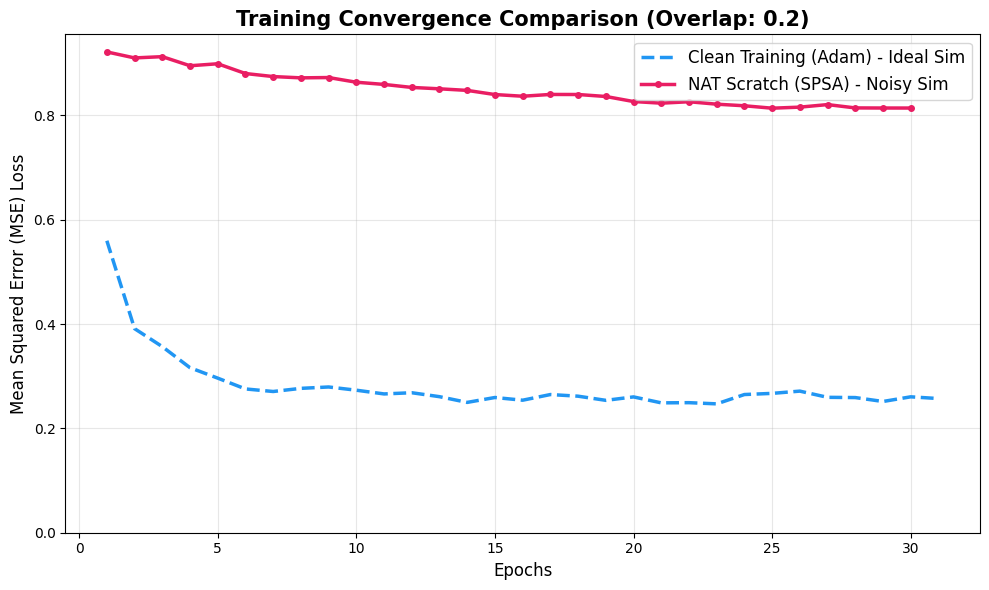

In [49]:
plt.figure(figsize=(10, 6))

# 1. Extraer la curva limpia (Adam) solo para el overlap seleccionado
clean_loss = vqc_losses[best_overlap]
epochs_clean = range(1, len(clean_loss) + 1)

plt.plot(epochs_clean, clean_loss, 
         label=f"Clean Training (Adam) - Ideal Sim", 
         color="#2196F3", linewidth=2.5, linestyle='--')

# 2. Extraer la curva ruidosa (SPSA) del NAT Scratch
epochs_scratch = range(1, len(loss_scratch) + 1)

plt.plot(epochs_scratch, loss_scratch, 
         label="NAT Scratch (SPSA) - Noisy Sim", 
         color="#E91E63", linewidth=2.5, marker='o', markersize=4)

# Estética de la gráfica
plt.title(f"Training Convergence Comparison (Overlap: {best_overlap})", fontsize=15, fontweight='bold')
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Mean Squared Error (MSE) Loss", fontsize=12)

# Añadimos un límite inferior de 0 para dar contexto visual al MSE
plt.ylim(bottom=0.0) 

plt.legend(fontsize=12)
plt.grid(axis='both', alpha=0.3)
plt.tight_layout()
plt.show()

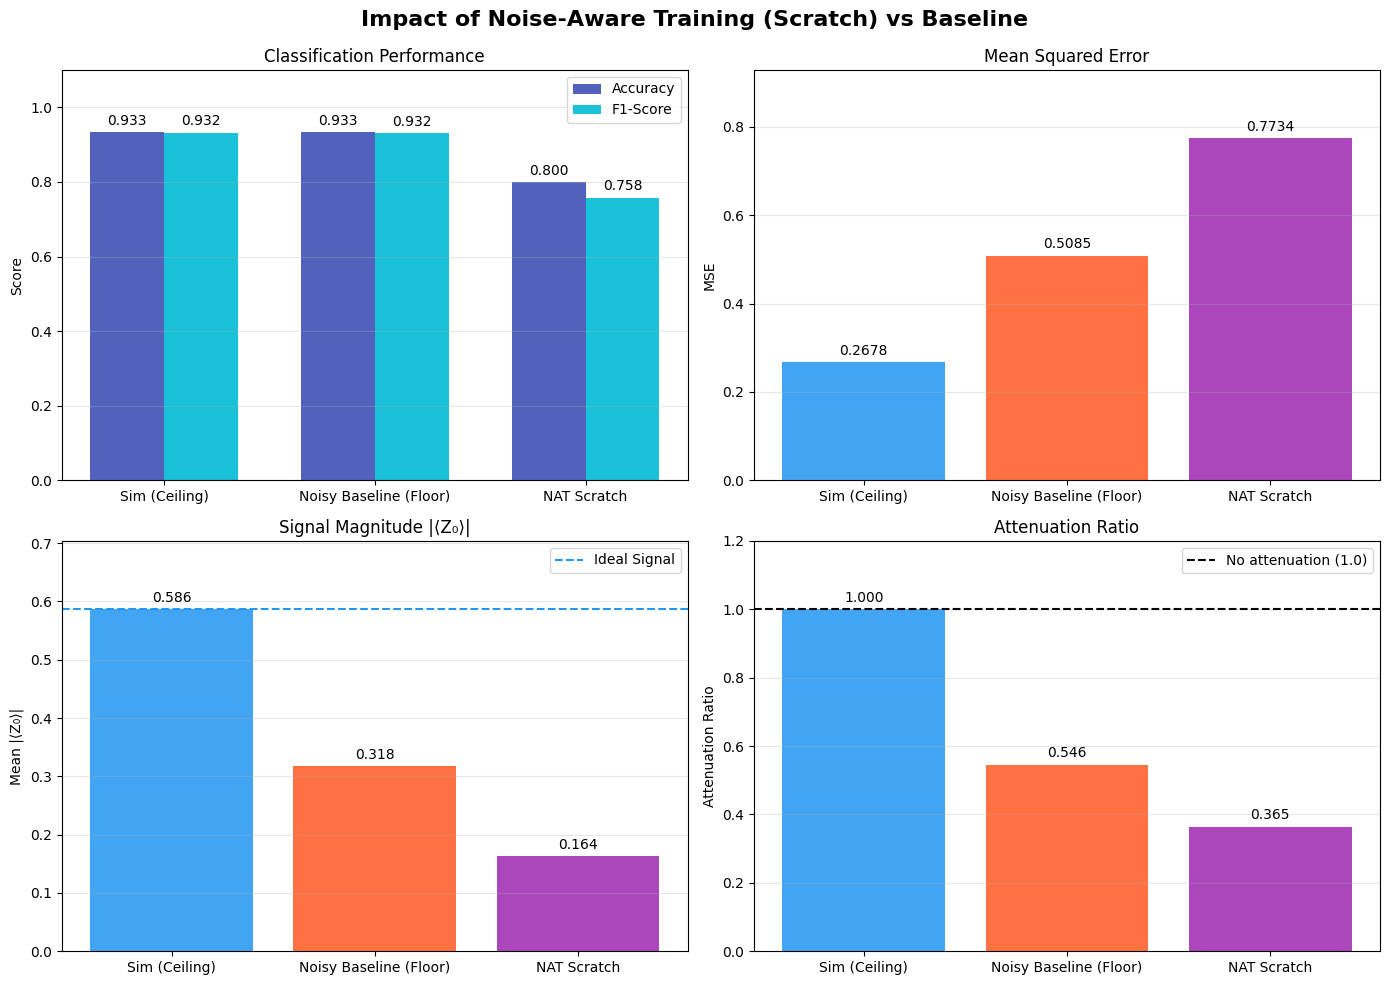

In [ ]:
# Collect data for the 3 specific conditions
comparison_data = {
    "Sim (Ceiling)": mitigation_results["sim (ceiling)"],
    "Noisy Baseline (Floor)": mitigation_results["baseline"],
    "NAT Scratch": m_scratch
}

names = list(comparison_data.keys())
acc = [comparison_data[n]['accuracy'] for n in names]
f1 = [comparison_data[n]['f1'] for n in names]
mse = [comparison_data[n]['mse'] for n in names]
z0 = [comparison_data[n]['mean_abs_z0'] for n in names]
att = [comparison_data[n]['attenuation'] for n in names]

# Define colors indicating the "quality" of the condition
colors = ["#2196F3", "#FF5722", "#9C27B0"] # Blue (Ideal), Orange (Worst), Purple (NAT)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Impact of Noise-Aware Training (Scratch) vs Baseline", fontsize=16, fontweight='bold')

# Helper function to annotate bars
def annotate_bars(ax, format_str="{:.3f}"):
    for p in ax.patches:
        ax.annotate(format_str.format(p.get_height()), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 8), 
                    textcoords='offset points', fontsize=10)


# Accuracy & F1-Score (Grouped bars)
ax = axes[0, 0]
x = np.arange(len(names))
width = 0.35

ax.bar(x - width/2, acc, width, label='Accuracy', color='#3F51B5', alpha=0.9)
ax.bar(x + width/2, f1, width, label='F1-Score', color='#00BCD4', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("Score")
ax.set_title("Classification Performance")
ax.set_ylim(0.0, 1.1)
ax.legend()
annotate_bars(ax, "{:.3f}")
ax.grid(axis='y', alpha=0.3)


#  Mean Squared Error (MSE)
ax = axes[0, 1]
ax.bar(names, mse, color=colors, alpha=0.85)

ax.set_ylabel("MSE")
ax.set_title("Mean Squared Error")
ax.set_ylim(0, max(mse) * 1.2)
annotate_bars(ax, "{:.4f}")
ax.grid(axis='y', alpha=0.3)


# Signal Magnitude |⟨Z₀⟩|
ax = axes[1, 0]
ax.bar(names, z0, color=colors, alpha=0.85)
ax.axhline(z0[0], color=colors[0], linestyle='--', linewidth=1.5, label='Ideal Signal')

ax.set_ylabel("Mean |⟨Z₀⟩|")
ax.set_title("Signal Magnitude |⟨Z₀⟩|")
ax.set_ylim(0, max(z0) * 1.2)
ax.legend()
annotate_bars(ax, "{:.3f}")
ax.grid(axis='y', alpha=0.3)


# Attenuation Ratio
ax = axes[1, 1]
ax.bar(names, att, color=colors, alpha=0.85)
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='No attenuation (1.0)')

ax.set_ylabel("Attenuation Ratio")
ax.set_title("Attenuation Ratio")
ax.set_ylim(0, 1.2)
ax.legend()
annotate_bars(ax, "{:.3f}")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.subplots_adjust(top=0.92)
plt.show()

In [51]:
# FINE-TUNING WITH SPSA (NAT Basic and NAT + REM)
import time
print(f"\n--- Starting NAT Fine-Tuning (SPSA) from clean weights ---")

EPOCHS_FINETUNE = 5 

# Model A: Fine-tuning on Basic NAT
t0_A = time.time()
weights_A, loss_A = train_spsa(
    cost_a_nat_basic, w_best, 
    d_best["X_train"], d_best["y_train"], 
    epochs=EPOCHS_FINETUNE, batch_size=16, label="Model A (NAT Basic Fine-Tune)"
)
time_A = time.time() - t0_A

# Model B: Fine-tuning on NAT + REM
t0_B = time.time()
weights_B, loss_B = train_spsa(
    cost_b_nat_rem, w_best, 
    d_best["X_train"], d_best["y_train"], 
    epochs=EPOCHS_FINETUNE, batch_size=16, label="Model B (NAT+REM Fine-Tune)"
)
time_B = time.time() - t0_B


--- Starting NAT Fine-Tuning (SPSA) from clean weights ---

Training Model A (NAT Basic Fine-Tune) (5 epochs)...
  [Model A (NAT Basic Fine-Tune)] Epoch  1/5 | Loss: 0.5157
  [Model A (NAT Basic Fine-Tune)] Epoch  2/5 | Loss: 0.5075
  [Model A (NAT Basic Fine-Tune)] Epoch  3/5 | Loss: 0.5128
  [Model A (NAT Basic Fine-Tune)] Epoch  4/5 | Loss: 0.5072
  [Model A (NAT Basic Fine-Tune)] Epoch  5/5 | Loss: 0.5079

Training Model B (NAT+REM Fine-Tune) (5 epochs)...
  [Model B (NAT+REM Fine-Tune)] Epoch  1/5 | Loss: 0.4676
  [Model B (NAT+REM Fine-Tune)] Epoch  2/5 | Loss: 0.4718
  [Model B (NAT+REM Fine-Tune)] Epoch  3/5 | Loss: 0.4716
  [Model B (NAT+REM Fine-Tune)] Epoch  4/5 | Loss: 0.4700
  [Model B (NAT+REM Fine-Tune)] Epoch  5/5 | Loss: 0.4725


In [52]:
print("\n=== FINE-TUNING COMPUTATIONAL TIME ===")
print(f"Model A (Basic NAT) : {time_A:.2f} s  ({time_A/60:.2f} min)")
print(f"Model B (NAT + REM) : {time_B:.2f} s  ({time_B/60:.2f} min)")
print(f"Overhead penalty    : Model B is {time_B/time_A:.2f}x slower than Model A")


=== FINE-TUNING COMPUTATIONAL TIME ===
Model A (Basic NAT) : 636.96 s  (10.62 min)
Model B (NAT + REM) : 7074.36 s  (117.91 min)
Overhead penalty    : Model B is 11.11x slower than Model A


In [53]:
# EVALUATION OF NAT MODELS & MITIGATED INFERENCE

import pandas as pd

nat_results = {}

# Add baselines and scratch results for comparison context
nat_results["Sim Ceiling (Sec 9)"] = mitigation_results["sim (ceiling)"]
nat_results["Noisy Floor (Sec 9)"] = mitigation_results["baseline"]
nat_results["NAT Scratch (SPSA)"]  = m_scratch


# 1. Model A evaluated naturally (noisy environment)
print("\nEvaluating Model A (Fine-Tuned with Basic NAT)...")

scores_A_noisy = get_scores(score_baseline, weights_A, d_best["X_test"])
m_A_noisy = compute_all_metrics(scores_A_noisy, y_true, scores_sim_ref)
nat_results["Mod A -> Noisy"] = m_A_noisy
print(f"  [Noisy] acc={m_A_noisy['accuracy']:.3f} | mse={m_A_noisy['mse']:.4f}")

# 2. Model A evaluated applying ZNE in inference
print("\nEvaluating Model A applying ZNE in inference...")

scores_A_zne = get_scores(score_zne, weights_A, d_best["X_test"])
m_A_zne = compute_all_metrics(scores_A_zne, y_true, scores_sim_ref)
nat_results["Mod A -> ZNE"] = m_A_zne
print(f"  [ZNE]   acc={m_A_zne['accuracy']:.3f} | mse={m_A_zne['mse']:.4f}")


# 3. Model B evaluated natively
print("\nEvaluating Model B (Fine-Tuned with NAT + REM)...")

scores_B_rem = get_scores(score_rem, weights_B, d_best["X_test"])
m_B_rem = compute_all_metrics(scores_B_rem, y_true, scores_sim_ref)
nat_results["Mod B -> REM"] = m_B_rem
print(f"  [REM]   acc={m_B_rem['accuracy']:.3f} | mse={m_B_rem['mse']:.4f}")

# 4. Model B evaluated applying pure ZNE to its weights
print("\nEvaluating Model B applying ZNE in inference...")

scores_B_zne = get_scores(score_zne, weights_B, d_best["X_test"])
m_B_zne = compute_all_metrics(scores_B_zne, y_true, scores_sim_ref)
nat_results["Mod B -> ZNE"] = m_B_zne
print(f"  [ZNE]   acc={m_B_zne['accuracy']:.3f} | mse={m_B_zne['mse']:.4f}")


# Create and display DataFrame
df_nat = pd.DataFrame(nat_results).T
columns_order = ['accuracy', 'f1', 'mse', 'mean_abs_z0', 'attenuation']
df_nat = df_nat[columns_order]

print("\n=== SUMMARY: NOISE-AWARE TRAINING ===")
display(df_nat.style.format("{:.3f}")
        .background_gradient(cmap='viridis', subset=['accuracy', 'mean_abs_z0'])
        .background_gradient(cmap='Reds', subset=['mse'])
       )


Evaluating Model A (Fine-Tuned with Basic NAT)...
  [Noisy] acc=0.933 | mse=0.4968

Evaluating Model A applying ZNE in inference...
  [ZNE]   acc=0.907 | mse=0.4743

Evaluating Model B (Fine-Tuned with NAT + REM)...
  [REM]   acc=0.920 | mse=0.4590

Evaluating Model B applying ZNE in inference...
  [ZNE]   acc=0.900 | mse=0.4731

=== SUMMARY: NOISE-AWARE TRAINING ===


,accuracy,f1,mse,mean_abs_z0,attenuation
Sim Ceiling (Sec 9),0.933,0.932,0.268,0.586,1.000
Noisy Floor (Sec 9),0.933,0.932,0.508,0.318,0.546
NAT Scratch (SPSA),0.800,0.758,0.773,0.164,0.365
Mod A -> Noisy,0.933,0.933,0.497,0.326,0.556
Mod A -> ZNE,0.907,0.905,0.474,0.406,0.763
Mod B -> REM,0.920,0.918,0.459,0.367,0.627
Mod B -> ZNE,0.900,0.898,0.473,0.410,0.827


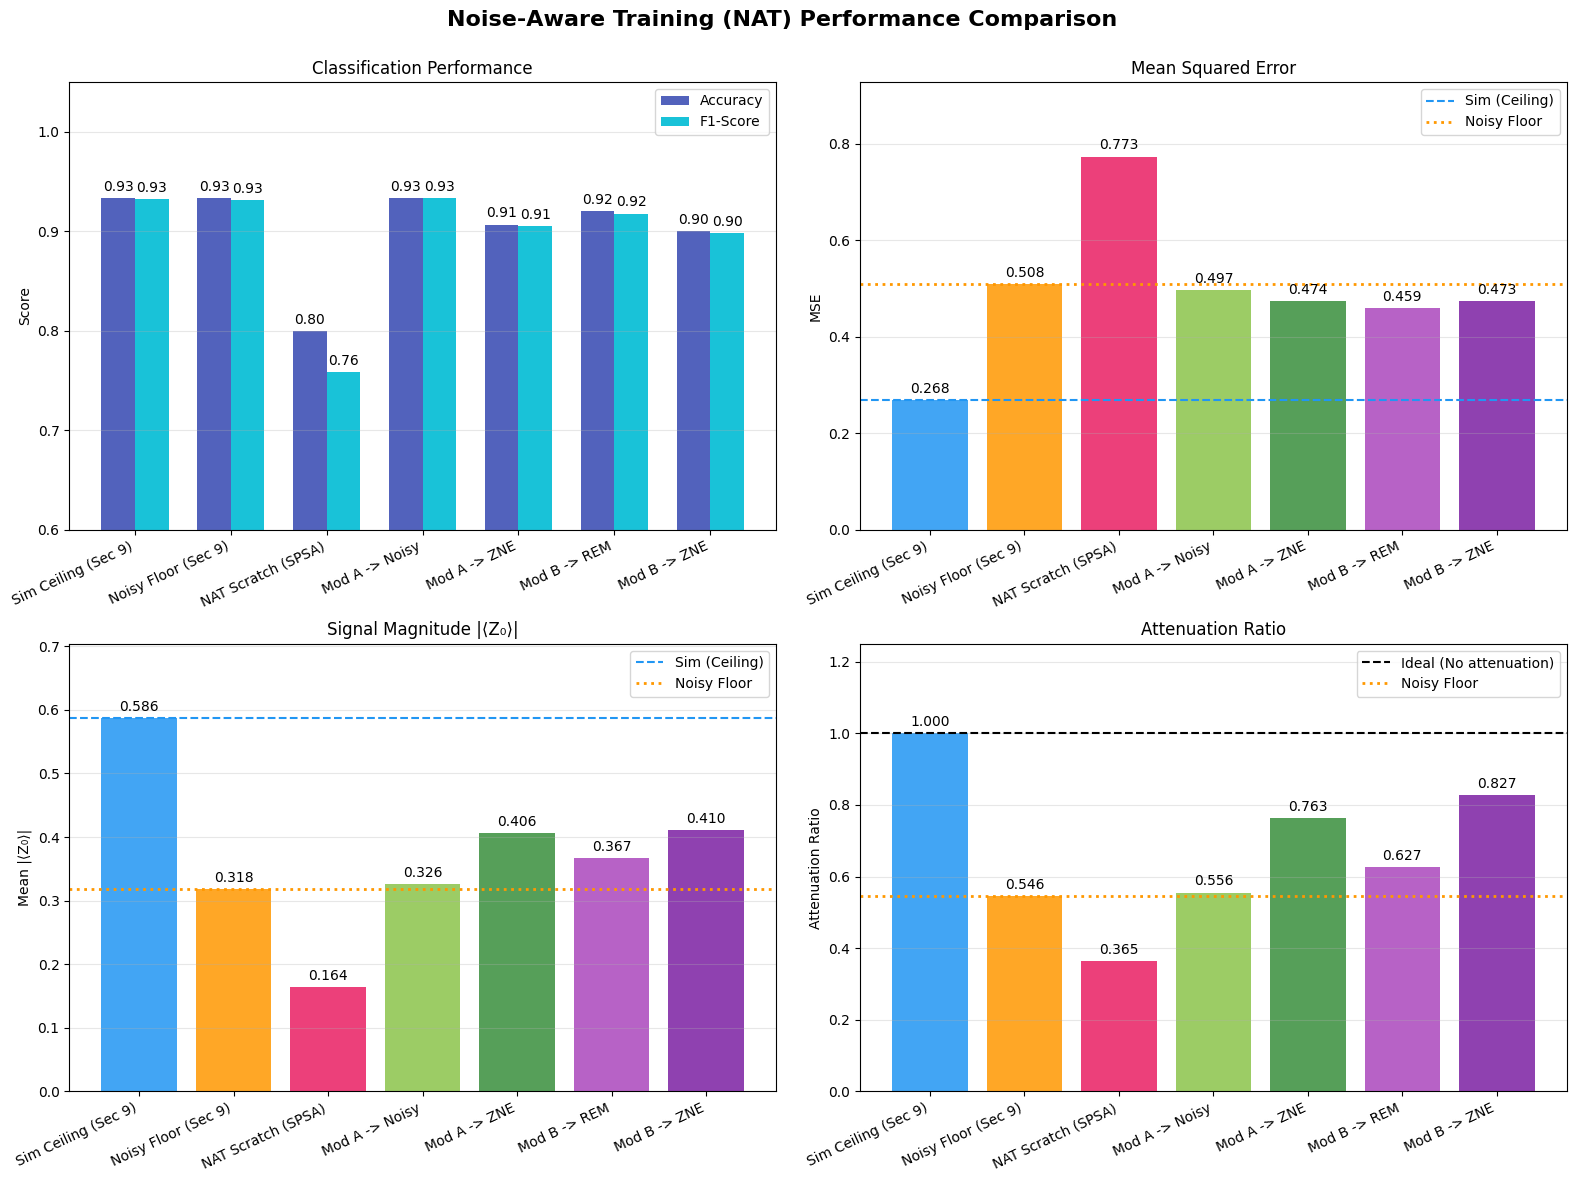

In [58]:
# Extract data from the nat_results dictionary
names = list(nat_results.keys())
acc = [nat_results[n]['accuracy'] for n in names]
f1  = [nat_results[n]['f1'] for n in names]
mse = [nat_results[n]['mse'] for n in names]
z0  = [nat_results[n]['mean_abs_z0'] for n in names]
att = [nat_results[n]['attenuation'] for n in names]

# Find indices for the baselines to draw reference lines
idx_sim   = names.index("Sim Ceiling (Sec 9)")
idx_floor = names.index("Noisy Floor (Sec 9)")

# Custom color palette for the 7 bars
colors = [
    "#2196F3", # Sim Ceiling (Blue)
    "#FF9800", # Noisy Floor (Orange)
    "#E91E63", # Scratch (Pink)
    "#8BC34A", # Mod A -> Noisy (Light Green)
    "#388E3C", # Mod A -> ZNE (Dark Green)
    "#AB47BC", # Mod B -> REM (Light Purple)
    "#7B1FA2"  # Mod B -> ZNE (Dark Purple)
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f"Noise-Aware Training (NAT) Performance Comparison", fontsize=16, fontweight='bold')

# Helper function to add value labels on top of the bars
def annotate_bars(ax, format_str="{:.3f}"):
    for p in ax.patches:
        ax.annotate(format_str.format(p.get_height()), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 8), 
                    textcoords='offset points', fontsize=10)


# Accuracy & F1-Score (Grouped bars)
ax = axes[0, 0]
x = np.arange(len(names))
width = 0.35

ax.bar(x - width/2, acc, width, label='Accuracy', color='#3F51B5', alpha=0.9)
ax.bar(x + width/2, f1, width, label='F1-Score', color='#00BCD4', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=25, ha='right')
ax.set_ylabel("Score")
ax.set_title("Classification Performance")
ax.set_ylim(0.6, 1.05) 
ax.legend()
annotate_bars(ax, "{:.2f}")
ax.grid(axis='y', alpha=0.3)


# Mean Squared Error (MSE)
ax = axes[0, 1]
ax.bar(names, mse, color=colors, alpha=0.85)

# Horizontal lines for Ceiling and Floor
ax.axhline(mse[idx_sim], color="#2196F3", linestyle='--', linewidth=1.5, label='Sim (Ceiling)')
ax.axhline(mse[idx_floor], color="#FF9800", linestyle=':', linewidth=2.0, label='Noisy Floor')

ax.set_xticklabels(names, rotation=25, ha='right')
ax.set_ylabel("MSE")
ax.set_title("Mean Squared Error")
ax.set_ylim(0, max(mse) * 1.2)
ax.legend()
annotate_bars(ax, "{:.3f}")
ax.grid(axis='y', alpha=0.3)


# Signal Magnitude |⟨Z₀⟩|
ax = axes[1, 0]
ax.bar(names, z0, color=colors, alpha=0.85)

# Horizontal lines for Ceiling and Floor
ax.axhline(z0[idx_sim], color="#2196F3", linestyle='--', linewidth=1.5, label='Sim (Ceiling)')
ax.axhline(z0[idx_floor], color="#FF9800", linestyle=':', linewidth=2.0, label='Noisy Floor')

ax.set_xticklabels(names, rotation=25, ha='right')
ax.set_ylabel("Mean |⟨Z₀⟩|")
ax.set_title("Signal Magnitude |⟨Z₀⟩|")
ax.set_ylim(0, max(z0) * 1.2)
ax.legend()
annotate_bars(ax, "{:.3f}")
ax.grid(axis='y', alpha=0.3)


# Attenuation Ratio
ax = axes[1, 1]
ax.bar(names, att, color=colors, alpha=0.85)

# Horizontal lines for Ideal and Floor
ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5, label='Ideal (No attenuation)')
ax.axhline(att[idx_floor], color="#FF9800", linestyle=':', linewidth=2.0, label='Noisy Floor')

ax.set_xticklabels(names, rotation=25, ha='right')
ax.set_ylabel("Attenuation Ratio")
ax.set_title("Attenuation Ratio")
ax.set_ylim(0, 1.25)
ax.legend()
annotate_bars(ax, "{:.3f}")
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.subplots_adjust(top=0.92) # Adjust so title does not overlap
plt.show()

## 12. Final Conclusions: Impact of Noise and Mitigation Strategies (NAT)

The analysis of the experiments performed on noisy simulators (modeling IBM's quantum hardware) yields fundamental conclusions regarding the viability and training strategies of Variational Quantum Classifiers (VQC) in the NISQ era. Based on the obtained metrics, we can extract the following key observations:

### 1. The Challenge of Training from Scratch: *Noise-Induced Barren Plateaus*
The model trained from scratch under noisy conditions (**NAT Scratch**) exhibited the poorest overall performance, with a drastic drop in Accuracy (0.800) and the highest Mean Squared Error (0.773) among all scenarios. Furthermore, its signal attenuation collapsed to 0.365. 
* **Theoretical Justification:** As clearly observed in its training Loss curve, **it is practically impossible for the model to converge**. This provides empirical evidence of the phenomenon known as *Noise-Induced Barren Plateaus*. The stochastic noise from the hardware flattens the gradients during the initial epochs, preventing the optimizer (SPSA) from finding a clear path toward the global minimum. This demonstrates that training deep QML models from random weight initializations directly on current quantum hardware is highly inefficient and often unfeasible.

### 2. The Necessity and Efficacy of Fine-Tuning (Model A)
To bypass the convergence issue, a hybrid approach was proposed: training the model on an ideal simulator and subsequently performing a noisy Fine-Tuning (**Mod A -> Noisy**).
* **Results:** This strategy successfully maintained the Accuracy (0.933) compared to the *Noisy Floor*, but managed to **reduce the MSE (from 0.508 down to 0.497)** and slightly recover the signal attenuation (from 0.546 to 0.556).
* **Conclusion:** Allowing the model to make micro-adjustments under the influence of noise enables the parametric rotations to recalibrate and compensate for the natural decoherence of the device, without losing the generalization capabilities learned in the ideal simulator.

### 3. Mitigation Integrated into Training: NAT + REM (Model B)
**Model B**, which integrated Readout Error Mitigation (REM) directly into the SPSA optimization loop, achieved the **best MSE of all noisy models (0.459)**, moving significantly closer to the ideal ceiling (0.268). Additionally, it recovered 62.7% of the original signal magnitude.
* **The Computational Trade-off:** While embedding classical techniques (like Mthree's matrix inversion) inside the training loop generates mathematically robust models, the temporal cost (*overhead penalty*) increases drastically. During our experiments, **Model A took 10.62 minutes (636.96 s)** to fine-tune, whereas **Model B took 117.91 minutes (7074.36 s)**. This means **Model B is 11.11x slower** than Model A. By breaking the parallel execution (batching) of the simulator, this approach presents a massive bottleneck. In real-world quantum hardware billed by execution time, researchers must carefully weigh whether the slight improvement in MSE justifies the radical increase in computational cost.

### 4. The Danger of Out-of-Distribution Extrapolation (ZNE)
One of the most notable experimental findings of this study is the reaction of NAT models when Zero Noise Extrapolation (ZNE) is applied during inference (**Mod A -> ZNE** and **Mod B -> ZNE**).
* **Observation:** In both cases, ZNE physically did what it is designed to do: de-attenuate the signal. The attenuation ratio rose dramatically to 0.763 and 0.827, respectively. However, **the Accuracy decreased to ~0.90**.
* **Explanation:** When a model is explicitly trained in the presence of noise (NAT), its weights broaden and deform to adapt to that specific environment ($\lambda = 1$). By applying ZNE during inference, we force the circuit to be evaluated in a virtual noise-free environment ($\lambda = 0$). The model finds itself operating "out-of-distribution", causing the compensatory rotations it learned to overcompensate. This creates "overshooting", increasing the variance of the predictions and causing data points to incorrectly cross the decision boundary (0.0).